In [18]:
import pandas as pd
import numpy as np
from portfolio_optimizer.optimizer import StaticOptimizer
from portfolio_optimizer.constraints import create_style_constraints
from portfolio_optimizer.reporting import PortfolioReporter

print("Quant Toolkit Imported Successfully.")

Quant Toolkit Imported Successfully.


In [19]:
# Generate dummy data locally to completely decouple from external CSV files.
np.random.seed(42) # Set seed for reproducibility

n_assets = 8
assets = [f'Asset_{chr(65+i)}' for i in range(n_assets)] 

# 1. Generate random expected returns (between 2% and 15%)
mu_dummy = np.random.uniform(0.02, 0.15, n_assets)

# 2. Generate a random Positive Semi-Definite (PSD) covariance matrix
A = np.random.rand(n_assets, n_assets)
cov_dummy = np.dot(A, A.T) * 0.01

# 3. Set risk-free rate and sector constraints (assume first 3 assets are 'Tech')
rf_annual = 0.02
tech_assets = ['Asset_A', 'Asset_B', 'Asset_C']

print(f"Generated {n_assets} Dummy Assets for testing.")

Generated 8 Dummy Assets for testing.


In [20]:
# Feed the dummy data into the custom optimization engine
opt_engine = StaticOptimizer(mu_dummy, cov_dummy)

# Dynamically generate constraints: 40% single-asset cap, Tech sector bounded between 30% and 50%
bounds = tuple((0.0, 0.40) for _ in range(opt_engine.n_assets))
style_cons = create_style_constraints(assets, tech_assets, w_low=0.30, w_high=0.50)

# Solve for Maximum Sharpe and Target Return portfolios
res_ms = opt_engine.maximize_sharpe(rf=rf_annual, bounds=bounds, constraints=style_cons)
res_tr = opt_engine.target_return(target=0.08, bounds=bounds, constraints=style_cons) 

w_ms = np.clip(res_ms.x, 0, 1)
w_tr = np.clip(res_tr.x, 0, 1)

print("Optimization Completed Successfully.")

Optimization Completed Successfully.



Performance Summary:


,Return,Volatility,Sharpe
Portfolio,,,
Max Sharpe,13.18%,12.75%,0.8767
Target Return,8.00%,10.57%,0.5676


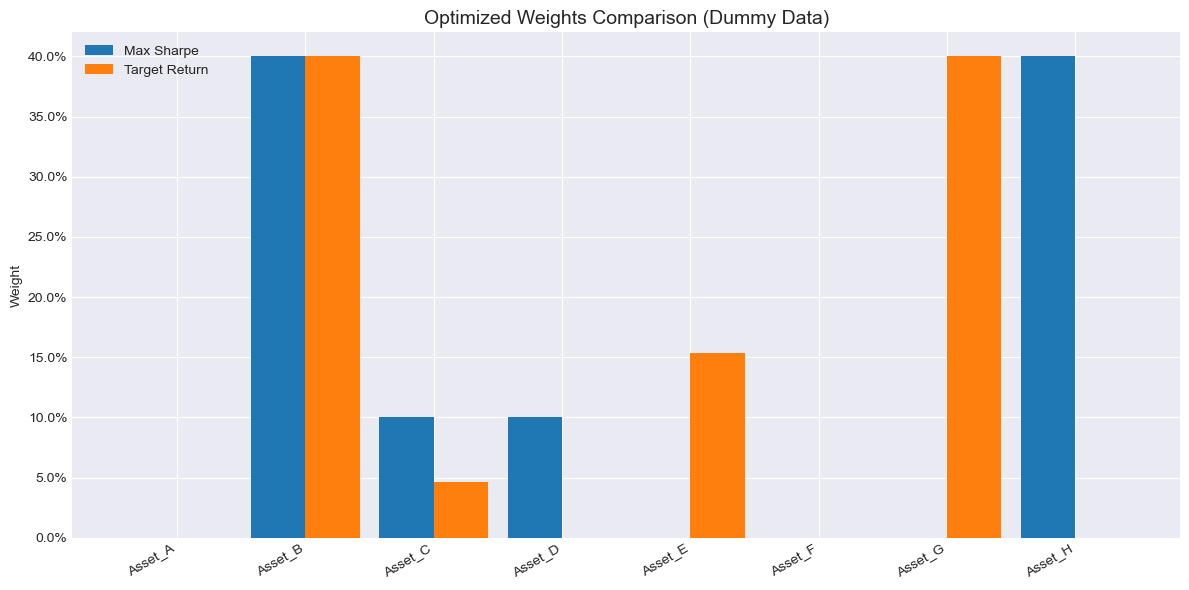

Pie chart saved to final_pie.png


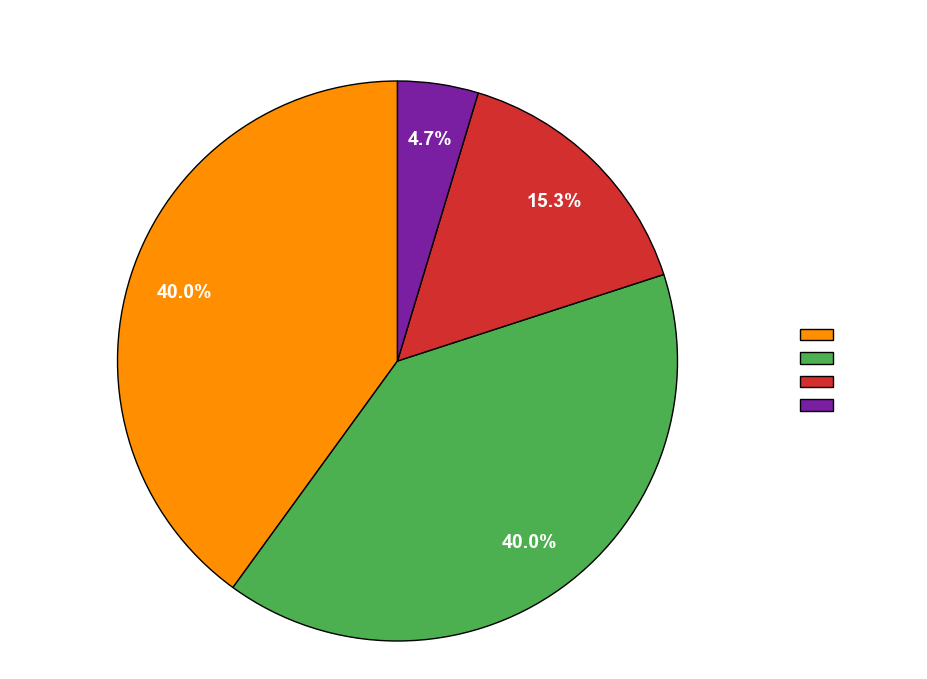

In [21]:
# Initialize the reporting module
reporter = PortfolioReporter(assets, rf_rate=rf_annual)

# 1. Generate performance comparison table
portfolios = {'Max Sharpe': w_ms, 'Target Return': w_tr}
summary_df = reporter.create_summary_table(portfolios, opt_engine.mu, opt_engine.cov)

print("\nPerformance Summary:")
display(reporter.format_performance_table(summary_df))

# 2. Plot grouped bar chart for weight comparison
weights_df = pd.DataFrame(portfolios, index=assets)
reporter.plot_weights_grouped(weights_df, title="Optimized Weights Comparison (Dummy Data)")

# 3. Plot pie chart for the Target Return portfolio allocation
final_weights_series = pd.Series(w_tr, index=assets)
reporter.plot_allocation_pie(final_weights_series, title="Target Return Allocation", save_path="final_pie.png")